***Key Questions***

**What are the key factors that influence medical insurance charges?**

**Is the evidence of bias or disparity in insurance charges based on demographic features?**

**Can we train a machine learning model accurately to predict insurance charges based on customer features?**


# **Section1: Import Liberaries and dataset:**

In [1]:
# Import essential libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load the insurance dataset
df = pd.read_csv('insurance.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

Dataset shape: (1338, 7)

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Basic statistics:
  

# **Section2: Exploratory Data Analysis**

Missing values: age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Data types: age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
Basic statistics:                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


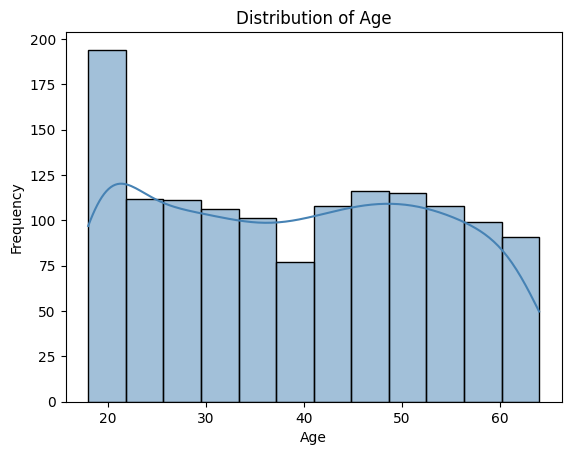

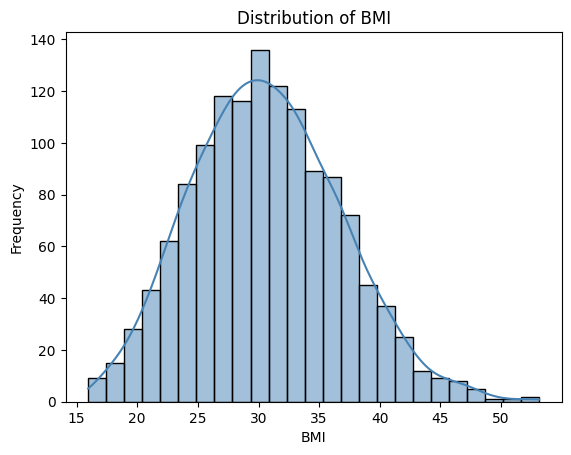

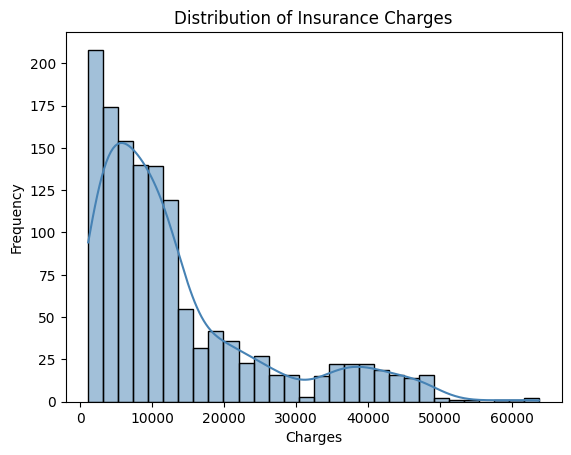

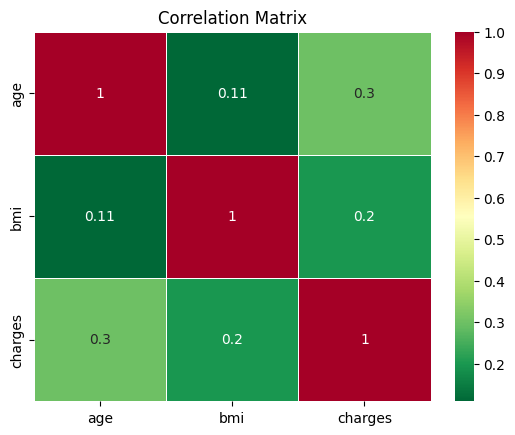

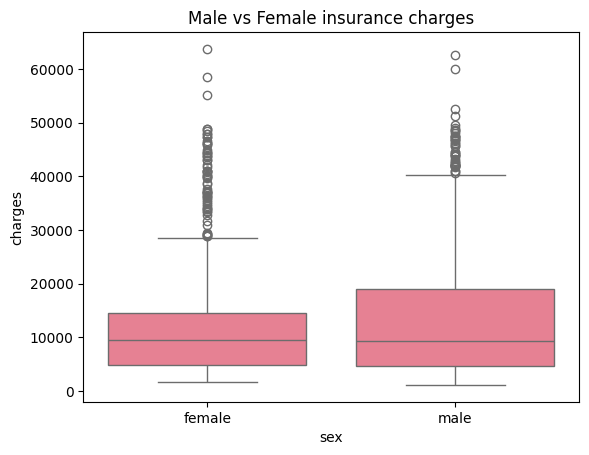

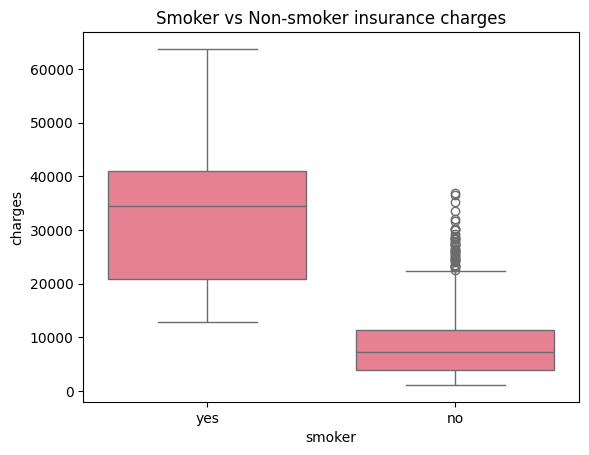

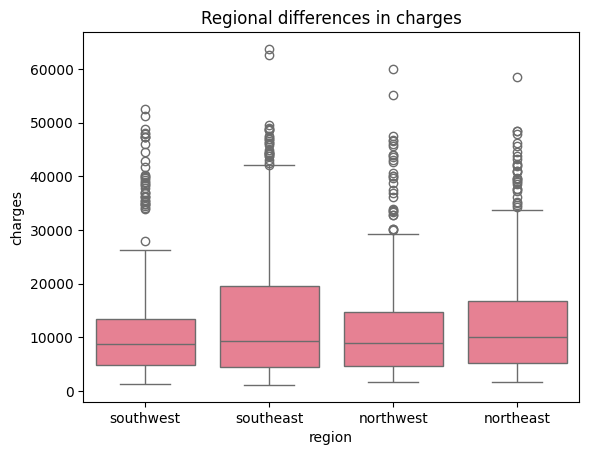

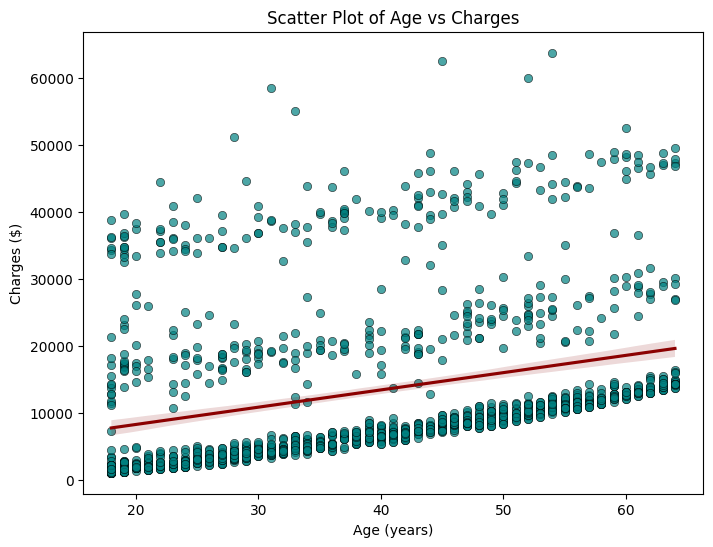

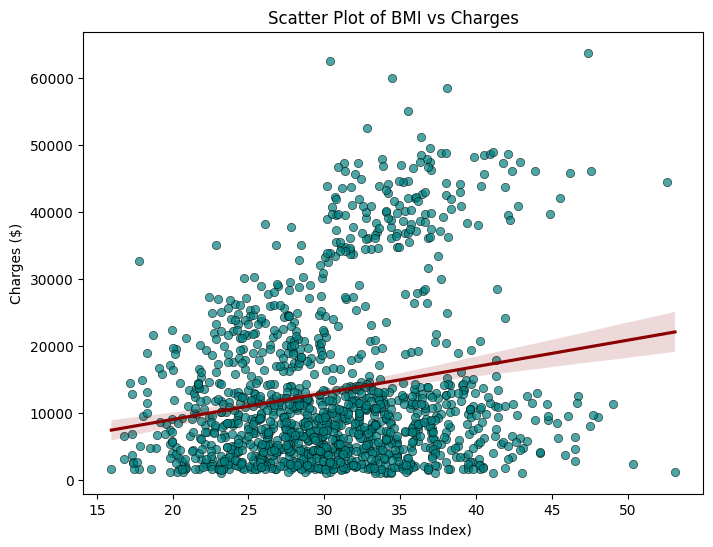

ANOVA Test for Charges across Age Groups: F-statistic: 38.93, P-value: 0.0000
T-test for Charges between '18-35' and '35-60': T-statistic: -7.43, P-value: 0.0000
T-test for Charges between Male and Female: T-statistic: 2.10, P-value: 0.0361
T-test for Charges between Smokers and Non-Smokers: T-statistic: 46.66, P-value: 0.0000


In [2]:
# SECTION 2: EXPLORATORY DATA ANALYSIS
# 1. BASIC DATA EXPLORATION
print("Missing values:", df.isnull().sum())
print("Data types:", df.dtypes)
print("Basic statistics:", df.describe())

# 2. DISTRIBUTION ANALYSIS
sns.histplot(data=df, x='age', kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

sns.histplot(data=df, x='bmi', kde=True, color='steelblue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

sns.histplot(data=df, x='charges', kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# 3. CORRELATION ANALYSIS
selected_columns = df[['age','bmi', 'charges']]
sns.heatmap(selected_columns.corr(), cmap='RdYlGn_r', linewidths=0.5, annot=True)
plt.title('Correlation Matrix')
plt.show()

# 4. BIAS DETECTION ANALYSIS
bins1 = [0, 18, 35, 60, np.inf]
names1 = ['<18', '18-35', '35-60', '60+']
df['AgeRange'] = pd.cut(df['age'], bins1, labels=names1)
bins2 = [0, 18.5, 24.9, 29.9, np.inf]
names2 = ['<18.5', '18.5-24.9', '25-29.9', '30+']
df['BMIRange'] = pd.cut(df['bmi'], bins2, labels=names2)

# 5. CATEGORICAL VARIABLE ANALYSIS
sns.boxplot(x="sex",y="charges",data=df)
plt.title('Male vs Female insurance charges')
plt.show()
sns.boxplot(x="smoker",y="charges",data=df)
plt.title('Smoker vs Non-smoker insurance charges')
plt.show()
sns.boxplot(x="region",y="charges",data=df)
plt.title('Regional differences in charges')
plt.show()

# 6. SCATTER PLOTS FOR RELATIONSHIPS
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='charges', color='teal', edgecolor='black', alpha=0.7)
sns.regplot(data=df, x='age', y='charges', scatter=False, color='darkred', line_kws={'label':"Linear Fit"})
plt.title('Scatter Plot of Age vs Charges')
plt.xlabel('Age (years)')
plt.ylabel('Charges ($)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='charges', color='teal', edgecolor='black', alpha=0.7)
sns.regplot(data=df, x='bmi', y='charges', scatter=False, color='darkred', line_kws={'label':"Linear Fit"})
plt.title('Scatter Plot of BMI vs Charges')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Charges ($)')
plt.show()

# 7. STATISTICAL TESTS
from scipy.stats import f_oneway, ttest_ind
df_anova = df.dropna(subset=['AgeRange', 'charges'])
age_group_charges = [df_anova['charges'][df_anova['AgeRange'] == group] for group in df_anova['AgeRange'].unique()]
f_statistic_anova, p_value_anova = f_oneway(*age_group_charges)
print(f"ANOVA Test for Charges across Age Groups: F-statistic: {f_statistic_anova:.2f}, P-value: {p_value_anova:.4f}")
charges_age_18_35 = df_anova['charges'][df_anova['AgeRange'] == '18-35']
charges_age_35_60 = df_anova['charges'][df_anova['AgeRange'] == '35-60']
if not charges_age_18_35.empty and not charges_age_35_60.empty:
    t_statistic_age, p_value_age = ttest_ind(charges_age_18_35, charges_age_35_60, equal_var=False)
    print(f"T-test for Charges between '18-35' and '35-60': T-statistic: {t_statistic_age:.2f}, P-value: {p_value_age:.4f}")
male_charges = df['charges'][df['sex'] == 'male']
female_charges = df['charges'][df['sex'] == 'female']
t_statistic_sex, p_value_sex = ttest_ind(male_charges, female_charges, equal_var=True)
print(f"T-test for Charges between Male and Female: T-statistic: {t_statistic_sex:.2f}, P-value: {p_value_sex:.4f}")
smoker_charges = df['charges'][df['smoker'] == 'yes']
non_smoker_charges = df['charges'][df['smoker'] == 'no']
t_statistic_smoker, p_value_smoker = ttest_ind(smoker_charges, non_smoker_charges, equal_var=True)
print(f"T-test for Charges between Smokers and Non-Smokers: T-statistic: {t_statistic_smoker:.2f}, P-value: {p_value_smoker:.4f}")

# **Secion3: Data Preprocessing and Cleaning**

In [3]:
# =========================================================
# 1. HANDLE MISSING VALUES
# =========================================================
# Load the dataset
df = pd.read_csv("insurance.csv")

# Check for missing values
print("Missing values before cleanup:\n", df.isnull().sum())

# In this dataset (based on inspection), there are no missing values.

# =========================================================
# 2. OUTLIER DETECTION AND TREATMENT
# =========================================================
# Using IQR method for 'charges', 'age', 'bmi'

def handle_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers instead of removing them
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))

for col in ['charges', 'age', 'bmi']:
    handle_outliers_iqr(col)

# Document the change
print("\nOutlier capping applied to columns: 'charges', 'age', 'bmi'")

# =========================================================
# 3. FEATURE ENCODING
# =========================================================
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
df['smoker_encoded'] = le.fit_transform(df['smoker'])

# One-Hot encode 'region'
df_encoded = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=True)

# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

def categorize_age(age):
    if age < 30:
        return 'Young'
    elif age < 45:
        return 'Middle-aged'
    elif age < 60:
        return 'Senior'
    else:
        return 'Elderly'

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_encoded['age_group'] = df_encoded['age'].apply(categorize_age)
df_encoded['bmi_category'] = df_encoded['bmi'].apply(categorize_bmi)

# =========================================================
# 5. FEATURE SCALING
# =========================================================
scaler = StandardScaler()
numerical_features = ['age', 'bmi', 'children']
df_scaled = df_encoded.copy()
df_scaled[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# =========================================================
# 6. DATA SPLITTING
# =========================================================
# Drop categorical columns that were used for feature engineering/analysis but are not yet encoded for modeling
# Also drop the original 'sex' and 'smoker' as their encoded versions are available
X = df_scaled.drop(['charges', 'sex', 'smoker', 'age_group', 'bmi_category'], axis=1)
y = df_scaled['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# =========================================================
# 7. BIAS MITIGATION CONSIDERATIONS
# =========================================================
# Observations:
# - Smokers represent a much smaller portion compared to non-smokers
# - Regions are moderately balanced
# - Age distribution skews younger


# =========================================================
# 8. FINAL DATA VALIDATION
# =========================================================
print("\nFinal validation:")
print("Missing values after processing:\n", df_scaled.isnull().sum())
print("Encoded columns:\n", [col for col in df_scaled.columns if 'encoded' in col or 'region' in col])
print("Check for leakage between train/test sets: None (split done before scaling target)")

Missing values before cleanup:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Outlier capping applied to columns: 'charges', 'age', 'bmi'

Training set size: (1070, 8)
Testing set size: (268, 8)

Final validation:
Missing values after processing:
 age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
sex_encoded         0
smoker_encoded      0
region_northwest    0
region_southeast    0
region_southwest    0
age_group           0
bmi_category        0
dtype: int64
Encoded columns:
 ['sex_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']
Check for leakage between train/test sets: None (split done before scaling target)


# **Section4: Model Training**


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 23437328.29
Root Mean Squared Error (RMSE): 4841.21
R-squared (R2 Score): 0.78
Mean Absolute Error (MAE): 3316.73

Random Forest Regressor Evaluation Metrics:
Mean Squared Error (MSE): 17956110.78
Root Mean Squared Error (RMSE): 4237.47
R-squared (R2 Score): 0.83
Mean Absolute Error (MAE): 2211.62

Gradient Boosting Regressor Evaluation Metrics:
Mean Squared Error (MSE): 18877942.38
Root Mean Squared Error (RMSE): 4344.88
R-squared (R2 Score): 0.83
Mean Absolute Error (MAE): 2528.35

Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 19050372.02
Root Mean Squared Error (RMSE): 4364.67
R-squared (R2 Score): 0.82
Mean Absolute Error (MAE): 1542.08

Ridge Regression Evaluation Metrics:
Mean Squared Error (MSE): 23437649.64
Root Mean Squared Error (RMSE): 4841.24
R-squared (R2 Score): 0.78
Mean Absolute Error (MAE): 3316.85

Lasso Regression Evaluation Metrics:
Mean Squared Error (MSE): 23437410.92
Root M

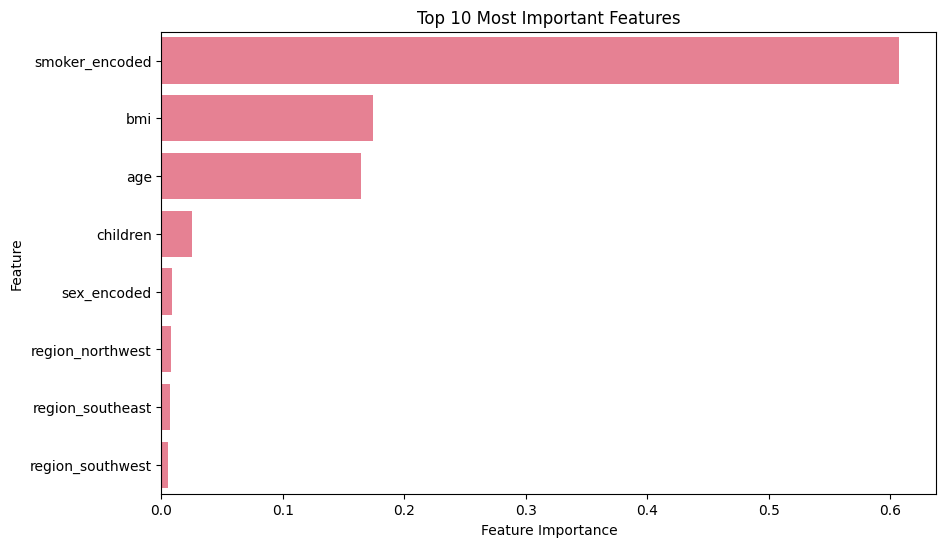


Model Performance Comparison:
                    Model          MSE        RMSE         MAE       R²
            Random Forest 1.795611e+07 4237.465136 2211.616484 0.834592
        Gradient Boosting 1.887794e+07 4344.875416 2528.348736 0.826100
Support Vector Regression 1.905037e+07 4364.673186 1542.079978 0.824512
        Linear Regression 2.343733e+07 4841.211449 3316.732530 0.784100
         Lasso Regression 2.343741e+07 4841.219983 3316.740890 0.784099
         Ridge Regression 2.343765e+07 4841.244637 3316.845796 0.784097

Linear Regression CV R² Score: 0.7306 (+/- 0.0992)
Random Forest CV R² Score: 0.7800 (+/- 0.0987)
Gradient Boosting CV R² Score: 0.7941 (+/- 0.0696)
Ridge Regression CV R² Score: 0.7306 (+/- 0.0992)
Lasso Regression CV R² Score: 0.7306 (+/- 0.0992)

Models and scaler saved successfully!


In [4]:
# SECTION 4: MODEL TRAINING
# Orlando/Zak
# Implement multiple regression models to predict insurance charges

# 1. BASELINE MODEL - LINEAR REGRESSION

# Train baseline linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate baseline model
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

# Printing Results of MSE, RMSE & R2 Score
print(f"\nLinear Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {lr_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.2f}")
print(f"R-squared (R2 Score): {lr_r2:.2f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.2f}")

# 2. ADVANCED MODEL - RANDOM FOREST

# Train Random Forest
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest model
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R-squared (R2 Score): {rf_r2:.2f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")

# 3. ADDITIONAL MODELS (OPTIONAL)

# - Gradient Boosting Regressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
gbrt.fit(X_train, y_train)

y_pred_gbrt = gbrt.predict(X_test)

gbrt_mse = mean_squared_error(y_test, y_pred_gbrt)
gbrt_rmse = np.sqrt(gbrt_mse)
gbrt_r2 = r2_score(y_test, y_pred_gbrt)
gbrt_mae = mean_absolute_error(y_test, y_pred_gbrt)

print("\nGradient Boosting Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {gbrt_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {gbrt_rmse:.2f}")
print(f"R-squared (R2 Score): {gbrt_r2:.2f}")
print(f"Mean Absolute Error (MAE): {gbrt_mae:.2f}")

# - Support Vector Regression

svr_rbf = SVR(kernel='rbf', C=1e4, gamma=0.1)
svr_rbf.fit(X_train, y_train)

y_pred_svr = svr_rbf.predict(X_test)

svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("\nSupport Vector Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {svr_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {svr_rmse:.2f}")
print(f"R-squared (R2 Score): {svr_r2:.2f}")
print(f"Mean Absolute Error (MAE): {svr_mae:.2f}")

# - Ridge/Lasso Regression for regularization

ridge = Ridge(alpha=0.01, random_state=42)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("\nRidge Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {ridge_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {ridge_rmse:.2f}")
print(f"R-squared (R2 Score): {ridge_r2:.2f}")
print(f"Mean Absolute Error (MAE): {ridge_mae:.2f}")

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("\nLasso Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {lasso_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lasso_rmse:.2f}")
print(f"R-squared (R2 Score): {lasso_r2:.2f}")
print(f"Mean Absolute Error (MAE): {lasso_mae:.2f}")

# 4. FEATURE IMPORTANCE ANALYSIS

# For Random Forest
feature_importance = rf_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
 }).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

# 5. BIAS ANALYSIS IN PREDICTIONS (Further analysis in Section 5)

# Add predictions to test set for analysis
test_analysis = X_test.copy()
test_analysis['actual_charges'] = y_test
test_analysis['predicted_charges_lr'] = y_pred_lr
test_analysis['predicted_charges_rf'] = y_pred_rf
test_analysis['predicted_charges_gbrt'] = y_pred_gbrt
test_analysis['predicted_charges_svr'] = y_pred_svr
test_analysis['predicted_charges_ridge'] = y_pred_ridge
test_analysis['predicted_charges_lasso'] = y_pred_lasso

# 6. MODEL COMPARISON

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Support Vector Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [lr_mse, rf_mse, gbrt_mse, svr_mse, ridge_mse, lasso_mse],
    'RMSE': [lr_rmse, rf_rmse, gbrt_rmse, svr_rmse, ridge_rmse, lasso_rmse],
    'MAE': [lr_mae, rf_mae, gbrt_mae, svr_mae, ridge_mae, lasso_mae],
    'R²': [lr_r2, rf_r2, gbrt_r2, svr_r2, ridge_r2, lasso_r2]
})

print("\nModel Performance Comparison:")
print(model_comparison.sort_values(by='R²', ascending=False).to_string(index=False))

# 7. CROSS-VALIDATION
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
cv_scores_gbrt = cross_val_score(gbrt, X_train, y_train, cv=5, scoring='r2')
cv_scores_ridge = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
cv_scores_lasso = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')

print(f"\nLinear Regression CV R² Score: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")
print(f"Random Forest CV R² Score: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")
print(f"Gradient Boosting CV R² Score: {cv_scores_gbrt.mean():.4f} (+/- {cv_scores_gbrt.std() * 2:.4f})")
print(f"Ridge Regression CV R² Score: {cv_scores_ridge.mean():.4f} (+/- {cv_scores_ridge.std() * 2:.4f})")
print(f"Lasso Regression CV R² Score: {cv_scores_lasso.mean():.4f} (+/- {cv_scores_lasso.std() * 2:.4f})")


# 8. SAVE TRAINED MODELS
import joblib

# Based on the model comparison, Random Forest or Gradient Boosting often perform well. Let's save both for now.
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(gbrt, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("\nModels and scaler saved successfully!")

# **Section5: Model Evaluation**

Setting up Model Evaluation Framework...
COMPREHENSIVE MODEL EVALUATION REPORT

Linear Regression Model Performance:
  MSE:  23437328.29
  RMSE: 4841.21
  MAE:  3316.73
  R²:   0.7841
  MAPE: 41.89%

Random Forest Model Performance:
  MSE:  17956110.78
  RMSE: 4237.47
  MAE:  2211.62
  R²:   0.8346
  MAPE: 31.45%

Gradient Boosting Model Performance:
  MSE:  18877942.38
  RMSE: 4344.88
  MAE:  2528.35
  R²:   0.8261
  MAPE: 32.66%

Support Vector Regression Model Performance:
  MSE:  19050372.02
  RMSE: 4364.67
  MAE:  1542.08
  R²:   0.8245
  MAPE: 6.92%

Ridge Regression Model Performance:
  MSE:  23437649.64
  RMSE: 4841.24
  MAE:  3316.85
  R²:   0.7841
  MAPE: 41.89%


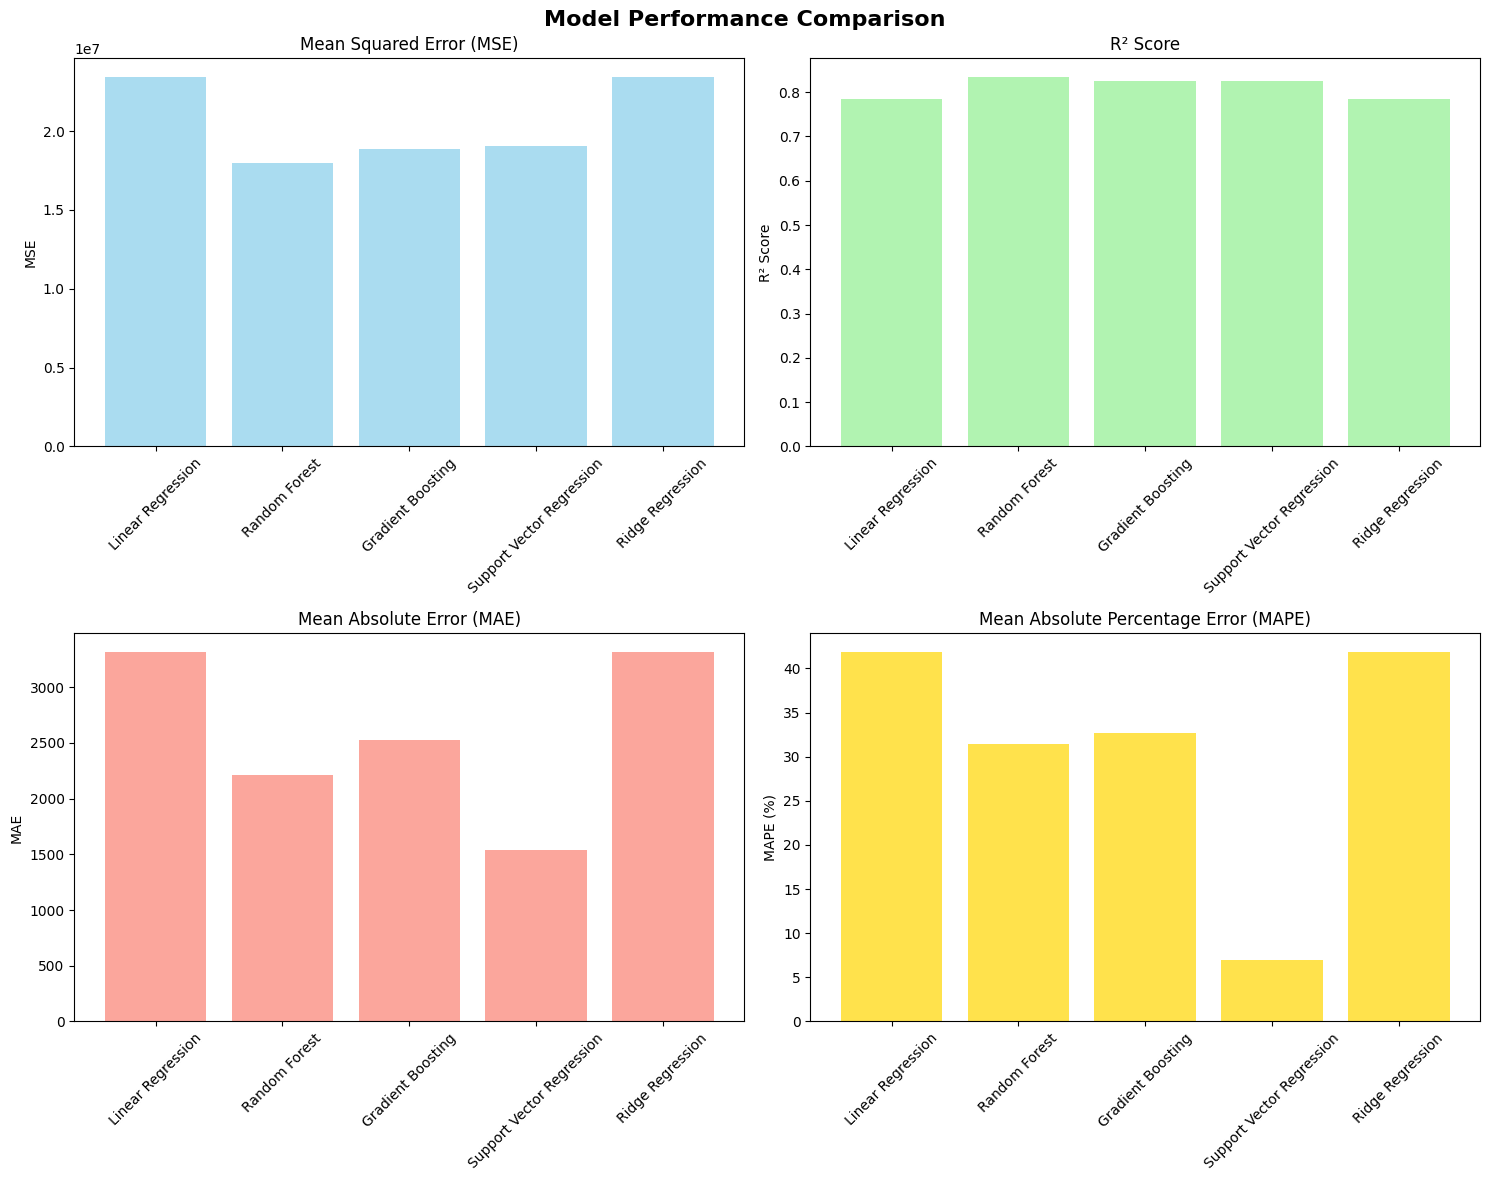

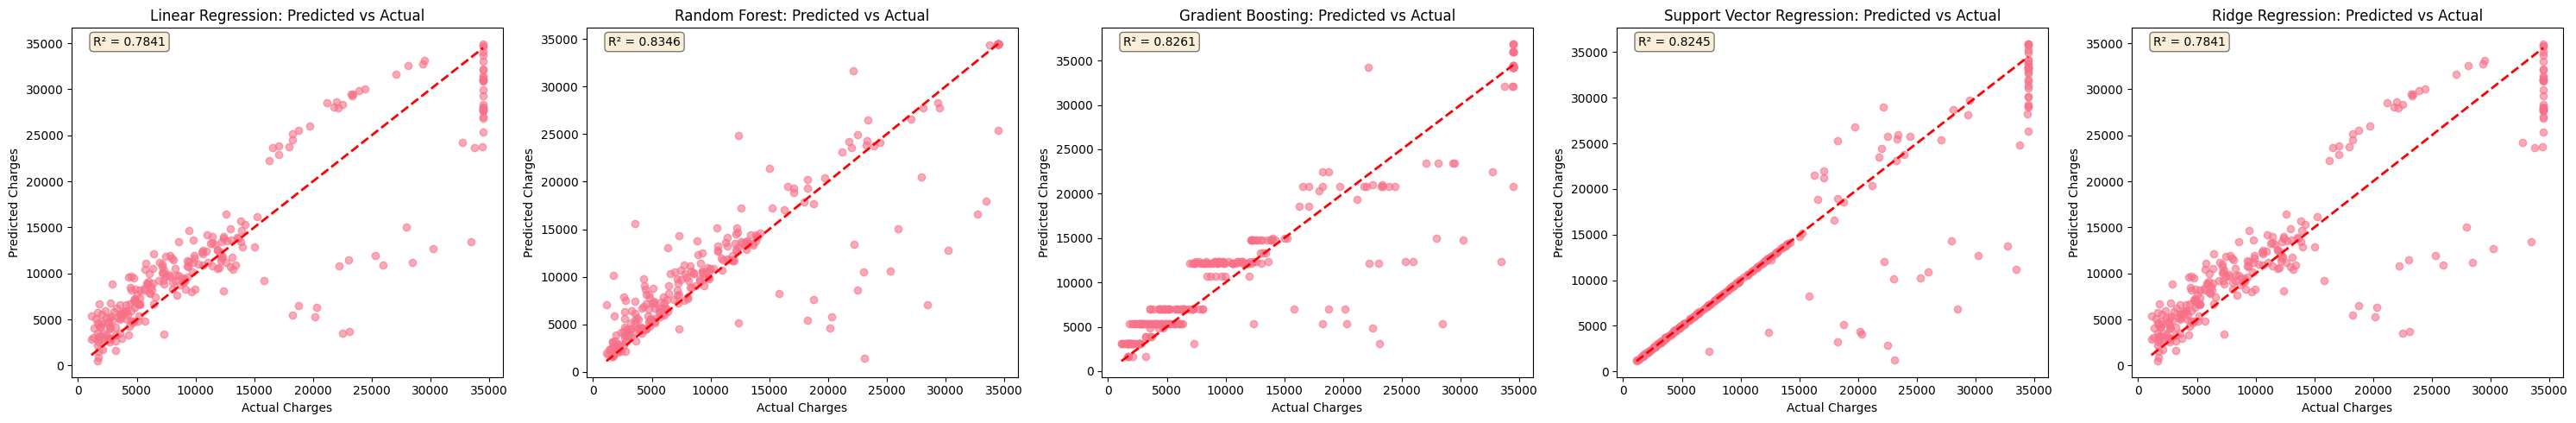

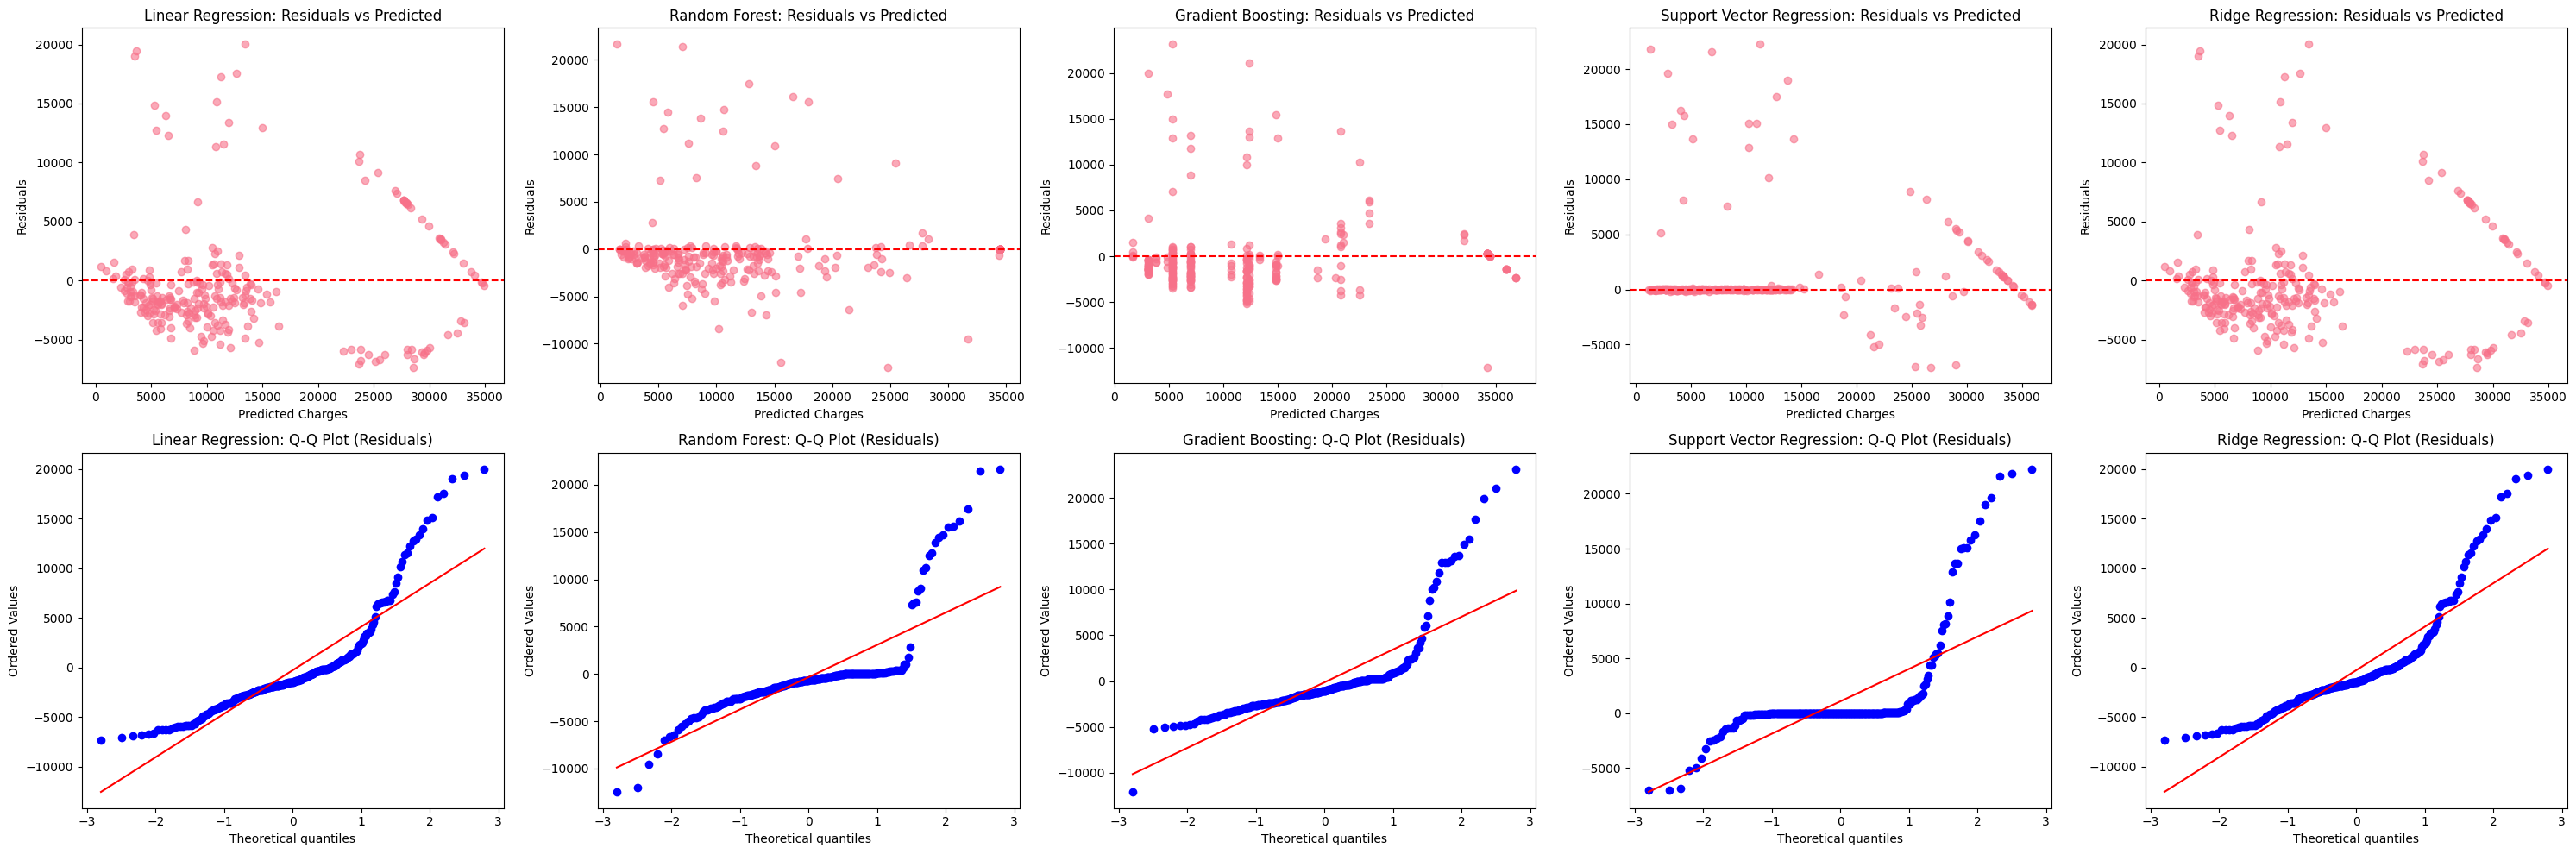

BIAS ANALYSIS IN MODEL PREDICTIONS

Bias Analysis by Age Group:

Linear Regression - Mean Absolute Error by Age Group:
age_group
Young      3122.446021
Middle             NaN
Senior             NaN
Elderly            NaN
Name: Linear Regression_abs_error, dtype: float64

Random Forest - Mean Absolute Error by Age Group:
age_group
Young      2267.768783
Middle             NaN
Senior             NaN
Elderly            NaN
Name: Random Forest_abs_error, dtype: float64

Gradient Boosting - Mean Absolute Error by Age Group:
age_group
Young      2910.204519
Middle             NaN
Senior             NaN
Elderly            NaN
Name: Gradient Boosting_abs_error, dtype: float64

Support Vector Regression - Mean Absolute Error by Age Group:
age_group
Young      1548.181649
Middle             NaN
Senior             NaN
Elderly            NaN
Name: Support Vector Regression_abs_error, dtype: float64

Ridge Regression - Mean Absolute Error by Age Group:
age_group
Young      3122.484143
Middle       

In [5]:
# SECTION 5: MODEL EVALUATION (Alex)
# Focus: Comprehensive evaluation of trained models with bias analysis

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import numpy as np
import pandas as pd

# =============================================================================
# EVALUATION FRAMEWORK - WORKS WITH ANY TRAINED MODELS FROM SECTION 4
# =============================================================================
def comprehensive_model_evaluation(models_dict, X_test, y_test, model_names=None):
    """
    Comprehensive evaluation function for multiple regression models
    """
    results = {}
    predictions = {}
    print("="*60)
    print("COMPREHENSIVE MODEL EVALUATION REPORT")
    print("="*60)
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        predictions[name] = y_pred
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        residuals = y_test - y_pred
        results[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'MAPE': mape,
            'Residuals': residuals
        }
        print(f"\n{name} Model Performance:")
        print(f"  MSE:  {mse:.2f}")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAE:  {mae:.2f}")
        print(f"  R²:   {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")
    return results, predictions

def create_evaluation_visualizations(results, predictions, y_test, X_test=None):
    """Create comprehensive evaluation visualizations"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    metrics_df = pd.DataFrame({
        model: {metric: values[metric] for metric in ['MSE', 'RMSE', 'MAE', 'R²', 'MAPE']}
        for model, values in results.items()
    }).T
    axes[0,0].bar(metrics_df.index, metrics_df['MSE'], alpha=0.7, color='skyblue')
    axes[0,0].set_title('Mean Squared Error (MSE)')
    axes[0,0].set_ylabel('MSE')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,1].bar(metrics_df.index, metrics_df['R²'], alpha=0.7, color='lightgreen')
    axes[0,1].set_title('R² Score')
    axes[0,1].set_ylabel('R² Score')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[1,0].bar(metrics_df.index, metrics_df['MAE'], alpha=0.7, color='salmon')
    axes[1,0].set_title('Mean Absolute Error (MAE)')
    axes[1,0].set_ylabel('MAE')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,1].bar(metrics_df.index, metrics_df['MAPE'], alpha=0.7, color='gold')
    axes[1,1].set_title('Mean Absolute Percentage Error (MAPE)')
    axes[1,1].set_ylabel('MAPE (%)')
    axes[1,1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    n_models = len(predictions)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    if n_models == 1:
        axes = [axes]
    for idx, (model_name, y_pred) in enumerate(predictions.items()):
        axes[idx].scatter(y_test, y_pred, alpha=0.6)
        axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[idx].set_xlabel('Actual Charges')
        axes[idx].set_ylabel('Predicted Charges')
        axes[idx].set_title(f'{model_name}: Predicted vs Actual')
        r2 = results[model_name]['R²']
        axes[idx].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[idx].transAxes,
                      bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()
    fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 10))
    if n_models == 1:
        axes = axes.reshape(-1, 1)
    for idx, (model_name, y_pred) in enumerate(predictions.items()):
        residuals = results[model_name]['Residuals']
        axes[0, idx].scatter(y_pred, residuals, alpha=0.6)
        axes[0, idx].axhline(y=0, color='r', linestyle='--')
        axes[0, idx].set_xlabel('Predicted Charges')
        axes[0, idx].set_ylabel('Residuals')
        axes[0, idx].set_title(f'{model_name}: Residuals vs Predicted')
        stats.probplot(residuals, dist="norm", plot=axes[1, idx])
        axes[1, idx].set_title(f'{model_name}: Q-Q Plot (Residuals)')
    plt.tight_layout()
    plt.show()

def bias_analysis_evaluation(predictions, y_test, X_test, df_original=None):
    """
    Analyze bias in model predictions across demographic groups
    Requires the original dataframe with categorical variables
    """
    print("="*60)
    print("BIAS ANALYSIS IN MODEL PREDICTIONS")
    print("="*60)
    if df_original is not None:
        bias_analysis_df = X_test.copy()
        bias_analysis_df['actual_charges'] = y_test
        for model_name, y_pred in predictions.items():
            bias_analysis_df[f'{model_name}_pred'] = y_pred
            bias_analysis_df[f'{model_name}_error'] = y_test - y_pred
            bias_analysis_df[f'{model_name}_abs_error'] = np.abs(y_test - y_pred)
        if 'age' in bias_analysis_df.columns:
            bias_analysis_df['age_group'] = pd.cut(bias_analysis_df['age'],
                                                 bins=[0, 30, 45, 60, 100],
                                                 labels=['Young', 'Middle', 'Senior', 'Elderly'])
            print("\nBias Analysis by Age Group:")
            for model_name in predictions.keys():
                print(f"\n{model_name} - Mean Absolute Error by Age Group:")
                age_bias = bias_analysis_df.groupby('age_group')[f'{model_name}_abs_error'].mean()
                print(age_bias)
        return bias_analysis_df
    else:
        print("Original dataframe not available. Cannot perform detailed bias analysis.")
        print("Please ensure df_original parameter includes demographic variables.")

# =============================================================================
# MAIN EVALUATION EXECUTION
# =============================================================================
print("Setting up Model Evaluation Framework...")
trained_models = {
    'Linear Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gbrt,
    'Support Vector Regression': svr_rbf,
    'Ridge Regression': ridge
}
results, predictions = comprehensive_model_evaluation(trained_models, X_test, y_test)
create_evaluation_visualizations(results, predictions, y_test, X_test)
bias_analysis_df = bias_analysis_evaluation(predictions, y_test, X_test, df)

**Linear Regression**

    -Strengths: Simple, readable, fast to train, good baseline for others.
   
    -Weaknesses: Assumes linear relationships. sensitive to outliers, limited for more complex patterns

**Random Forest**

    -Strengths: Handles non-linear relationships, resistant to outliers, reduces overfitting, provides feature importance.
   
    -Weaknesses:Less interpretable, can be slow with larger datasets, may overfit if not tuned correctly.

**Gradient Boosting**

    -Strengths: High Accuracy, Handles complex patterns, Flexible, can be tuned for performance.
    
    -Weaknesses: Sensitive to hyperparameters, longer training time, risk of overfitting

**Support Vector Regression**

    -Strengths: Effective for small/medium datasets (This one), handles non-linear data with kernels.
    
    -Weaknesses:Slow for large datasets, sensitive to parameter selection, less readable.

**Ridge/Lasso Regression**

    -Strengths:Regularisation reduces overfitting, handles multicollinearity (2 varaiable being too similar to provide uniqueness), lasso can select features
    
    -Weaknesses:Assumes Linear relationships, will do poorly on very non-linear data.

# Advanced
# **Section6: Module Hypertuning**

COMPREHENSIVE HYPERPARAMETER TUNING
Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF parameters: {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 25}
Best CV R² score: 0.8027
Tuning time: 12.10 seconds

Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best GB parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.01}
Best CV R² score: 0.7997
Tuning time: 4.39 seconds

Tuning Ridge Regression...
Best Ridge alpha: {'alpha': 1.0}
Best CV R² score: 0.7306

Tuning Lasso Regression...
Best Lasso alpha: {'alpha': 10.0}
Best CV R² score: 0.7307

HYPERPARAMETER TUNING RESULTS SUMMARY
            Model  Best_CV_R2  Tuning_Time_Seconds Method
    Random_Forest    0.802734            12.099447 random
Gradient_Boosting    0.799673             4.394889 random
            Lasso    0.

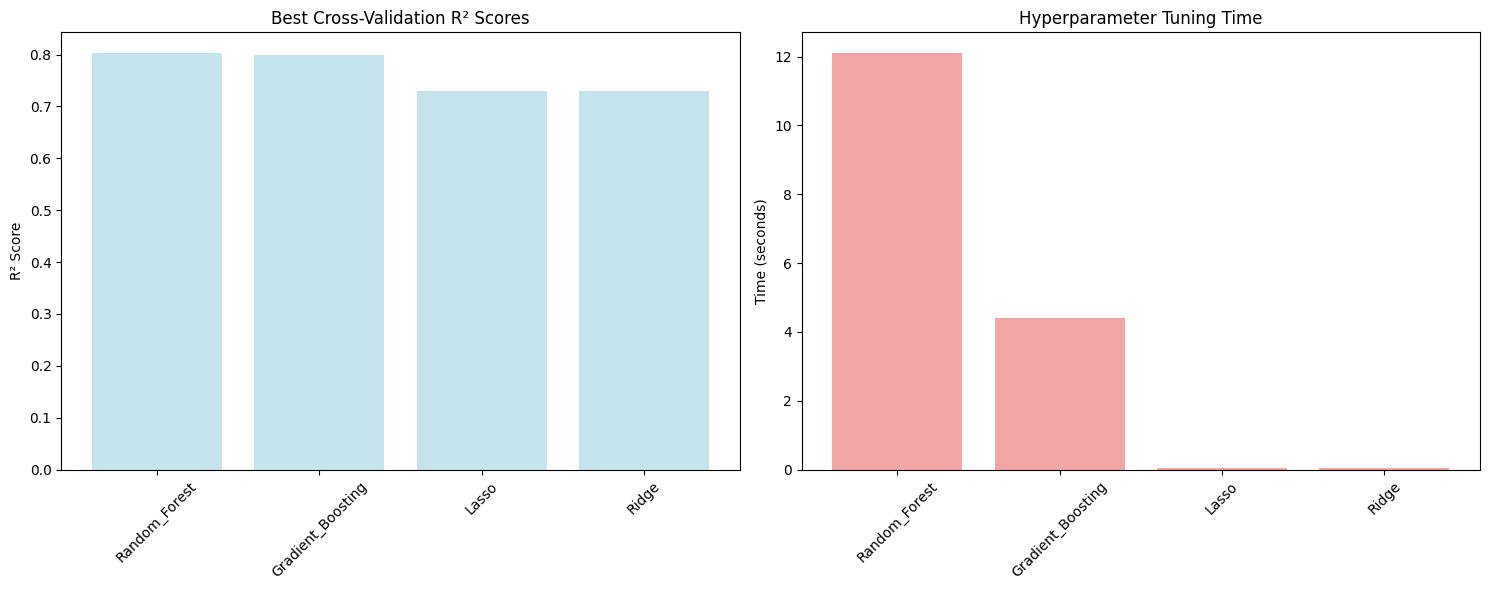


TUNED MODELS EVALUATION ON TEST SET

Random_Forest:
  Test R²:  0.8437
  Test MSE: 16962120.90
  Test MAE: 2198.69

Gradient_Boosting:
  Test R²:  0.8455
  Test MSE: 16774864.79
  Test MAE: 2386.16

Ridge:
  Test R²:  0.7838
  Test MSE: 23471361.90
  Test MAE: 3328.00

Lasso:
  Test R²:  0.7833
  Test MSE: 23525772.29
  Test MAE: 3325.09
Tuning complete. Results:
               Model  Best_CV_R2  Tuning_Time_Seconds  Method
0      Random_Forest    0.802734            12.099447  random
1  Gradient_Boosting    0.799673             4.394889  random
3              Lasso    0.730720             0.050609    grid
2              Ridge    0.730605             0.057682    grid
Test set evaluation of tuned models:
{'Random_Forest': {'MSE': 16962120.899207536, 'R²': 0.8437484768805438, 'MAE': 2198.6866822214943}, 'Gradient_Boosting': {'MSE': 16774864.792498631, 'R²': 0.845473441114707, 'MAE': 2386.155526518129}, 'Ridge': {'MSE': 23471361.900598597, 'R²': 0.7837867051856795, 'MAE': 3327.9977067334

In [6]:
# SECTION 6: Comprehensive Hyperparameter Tuning Framework
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
import time
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =============================================================================
# HYPERPARAMETER TUNING FRAMEWORK
# =============================================================================
class HyperparameterTuner:
    """Comprehensive hyperparameter tuning class for regression models"""
    def __init__(self, X_train, y_train, X_test, y_test, cv_folds=5, random_state=42):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.tuned_models = {}
        self.tuning_results = {}

    def tune_random_forest(self, method='grid', n_iter=20):
        print("Tuning Random Forest...")
        param_grid = {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }
        if method == 'random':
            param_grid.update({
                'n_estimators': [50, 100, 150, 200, 250, 300],
                'max_depth': [None, 5, 10, 15, 20, 25, 30],
                'min_samples_split': [2, 5, 10, 15],
                'min_samples_leaf': [1, 2, 4, 6],
            })
        rf = RandomForestRegressor(random_state=self.random_state)
        if method == 'grid':
            search = GridSearchCV(rf, param_grid, cv=self.cv_folds, scoring='r2', n_jobs=-1, verbose=1)
        else:
            search = RandomizedSearchCV(rf, param_grid, n_iter=n_iter, cv=self.cv_folds, scoring='r2', n_jobs=-1, verbose=1, random_state=self.random_state)
        start_time = time.time()
        search.fit(self.X_train, self.y_train)
        end_time = time.time()
        self.tuned_models['Random_Forest'] = search.best_estimator_
        self.tuning_results['Random_Forest'] = {
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'training_time': end_time - start_time,
            'method': method
        }
        print(f"Best RF parameters: {search.best_params_}")
        print(f"Best CV R² score: {search.best_score_:.4f}")
        print(f"Tuning time: {end_time - start_time:.2f} seconds")
        return search.best_estimator_

    def tune_gradient_boosting(self, method='grid', n_iter=20):
        print("\nTuning Gradient Boosting...")
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        if method == 'random':
            param_grid.update({
                'n_estimators': [50, 100, 150, 200, 250, 300],
                'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
                'max_depth': [3, 4, 5, 6, 7, 8],
                'subsample': [0.8, 0.9, 1.0]
            })
        gb = GradientBoostingRegressor(random_state=self.random_state)
        if method == 'grid':
            search = GridSearchCV(gb, param_grid, cv=self.cv_folds, scoring='r2', n_jobs=-1, verbose=1)
        else:
            search = RandomizedSearchCV(gb, param_grid, n_iter=n_iter, cv=self.cv_folds, scoring='r2', n_jobs=-1, verbose=1, random_state=self.random_state)
        start_time = time.time()
        search.fit(self.X_train, self.y_train)
        end_time = time.time()
        self.tuned_models['Gradient_Boosting'] = search.best_estimator_
        self.tuning_results['Gradient_Boosting'] = {
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'training_time': end_time - start_time,
            'method': method
        }
        print(f"Best GB parameters: {search.best_params_}")
        print(f"Best CV R² score: {search.best_score_:.4f}")
        print(f"Tuning time: {end_time - start_time:.2f} seconds")
        return search.best_estimator_

    def tune_ridge_regression(self):
        print("\nTuning Ridge Regression...")
        param_grid = {
            'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
        }
        ridge = Ridge(random_state=self.random_state)
        search = GridSearchCV(ridge, param_grid, cv=self.cv_folds, scoring='r2', n_jobs=-1)
        start_time = time.time()
        search.fit(self.X_train, self.y_train)
        end_time = time.time()
        self.tuned_models['Ridge'] = search.best_estimator_
        self.tuning_results['Ridge'] = {
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'training_time': end_time - start_time,
            'method': 'grid'
        }
        print(f"Best Ridge alpha: {search.best_params_}")
        print(f"Best CV R² score: {search.best_score_:.4f}")
        return search.best_estimator_

    def tune_lasso_regression(self):
        print("\nTuning Lasso Regression...")
        param_grid = {
            'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
        }
        lasso = Lasso(random_state=self.random_state, max_iter=2000)
        search = GridSearchCV(lasso, param_grid, cv=self.cv_folds, scoring='r2', n_jobs=-1)
        start_time = time.time()
        search.fit(self.X_train, self.y_train)
        end_time = time.time()
        self.tuned_models['Lasso'] = search.best_estimator_
        self.tuning_results['Lasso'] = {
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'training_time': end_time - start_time,
            'method': 'grid'
        }
        print(f"Best Lasso alpha: {search.best_params_}")
        print(f"Best CV R² score: {search.best_score_:.4f}")
        return search.best_estimator_

    def tune_all_models(self, search_method='random'):
        print("="*60)
        print("COMPREHENSIVE HYPERPARAMETER TUNING")
        print("="*60)
        self.tune_random_forest(method=search_method)
        self.tune_gradient_boosting(method=search_method)
        self.tune_ridge_regression()
        self.tune_lasso_regression()
        return self.tuned_models, self.tuning_results

    def compare_tuning_results(self):
        print("\n" + "="*60)
        print("HYPERPARAMETER TUNING RESULTS SUMMARY")
        print("="*60)
        results_df = pd.DataFrame({
            'Model': list(self.tuning_results.keys()),
            'Best_CV_R2': [results['best_score'] for results in self.tuning_results.values()],
            'Tuning_Time_Seconds': [results['training_time'] for results in self.tuning_results.values()],
            'Method': [results['method'] for results in self.tuning_results.values()]
        }).sort_values('Best_CV_R2', ascending=False)
        print(results_df.to_string(index=False))
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        ax1.bar(results_df['Model'], results_df['Best_CV_R2'], alpha=0.7, color='lightblue')
        ax1.set_title('Best Cross-Validation R² Scores')
        ax1.set_ylabel('R² Score')
        ax1.tick_params(axis='x', rotation=45)
        ax2.bar(results_df['Model'], results_df['Tuning_Time_Seconds'], alpha=0.7, color='lightcoral')
        ax2.set_title('Hyperparameter Tuning Time')
        ax2.set_ylabel('Time (seconds)')
        ax2.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
        return results_df

    def evaluate_tuned_models(self):
        print("\n" + "="*60)
        print("TUNED MODELS EVALUATION ON TEST SET")
        print("="*60)
        test_results = {}
        for name, model in self.tuned_models.items():
            y_pred = model.predict(self.X_test)
            mse = mean_squared_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)
            mae = mean_absolute_error(self.y_test, y_pred)
            test_results[name] = {
                'MSE': mse,
                'R²': r2,
                'MAE': mae
            }
            print(f"\n{name}:")
            print(f"  Test R²:  {r2:.4f}")
            print(f"  Test MSE: {mse:.2f}")
            print(f"  Test MAE: {mae:.2f}")
        return test_results

# =============================================================================
# MAIN TUNING EXECUTION
# =============================================================================
tuner = HyperparameterTuner(X_train, y_train, X_test, y_test)
tuned_models, tuning_results = tuner.tune_all_models(search_method='random')
results_df = tuner.compare_tuning_results()
test_results = tuner.evaluate_tuned_models()
print("Tuning complete. Results:")
print(results_df)
print("Test set evaluation of tuned models:")
print(test_results)

Alex Rush, Orlando Igwe, Zakaria Miah, Mohammed Shams